
# **Outlier Detection and Handling — Essential Codes**

Outliers are extreme values that differ significantly from other observations.

They can affect:
- Mean and variance
- Model performance
- Distance based algorithms

Common methods to detect outliers:

- Z-Score Method
- IQR Method
- Percentile Method



## **1. Import Required Libraries**


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



## **2. Create Sample Dataset**


In [2]:

data = pd.DataFrame({
    "salary":[25000,30000,32000,35000,37000,40000,42000,45000,47000,200000]
})

data


,salary
0,25000
1,30000
2,32000
3,35000
4,37000
5,40000
6,42000
7,45000
8,47000
9,200000



# **Visualizing Outliers**



## **3. Box Plot**
Boxplots help visually identify outliers.


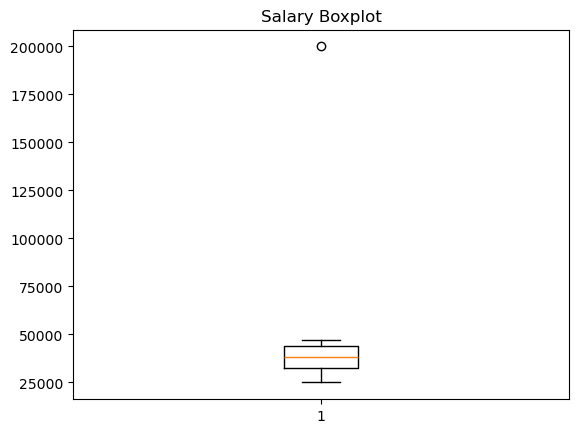

In [3]:

plt.boxplot(data["salary"])
plt.title("Salary Boxplot")
plt.show()



# **Z-Score Method**
Z-score measures how many standard deviations a value is from the mean.

Formula:

Z = (x − μ) / σ

Common rule:
|Z| > 3 → Outlier



## **4. Detect Outliers using Z-Score**


In [4]:

z_scores = np.abs(stats.zscore(data["salary"]))

outliers = data[z_scores > 3]

print(outliers)


Empty DataFrame
Columns: [salary]
Index: []



## **5. Remove Outliers using Z-Score**


In [5]:

clean_data = data[z_scores < 3]

clean_data


,salary
0,25000
1,30000
2,32000
3,35000
4,37000
5,40000
6,42000
7,45000
8,47000
9,200000



# **IQR Method (Interquartile Range)**

IQR = Q3 − Q1

Lower Bound = Q1 − 1.5 * IQR  
Upper Bound = Q3 + 1.5 * IQR



## **6. Detect Outliers using IQR**


In [6]:

Q1 = data["salary"].quantile(0.25)
Q3 = data["salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["salary"] < lower_bound) | (data["salary"] > upper_bound)]

print(outliers)


   salary
9  200000



## **7. Remove Outliers using IQR**


In [7]:

clean_data = data[(data["salary"] >= lower_bound) & (data["salary"] <= upper_bound)]

clean_data


,salary
0,25000
1,30000
2,32000
3,35000
4,37000
5,40000
6,42000
7,45000
8,47000



# **Percentile Method**

Extreme values can also be removed using percentile thresholds.

Example:

Remove values below 1st percentile and above 99th percentile.



## **8. Detect Outliers using Percentiles**


In [8]:

lower = data["salary"].quantile(0.01)
upper = data["salary"].quantile(0.99)

outliers = data[(data["salary"] < lower) | (data["salary"] > upper)]

print(outliers)


   salary
0   25000
9  200000



## **9. Remove Outliers using Percentiles**


In [9]:

clean_data = data[(data["salary"] >= lower) & (data["salary"] <= upper)]

clean_data


,salary
1,30000
2,32000
3,35000
4,37000
5,40000
6,42000
7,45000
8,47000



# **Summary**

Common outlier detection techniques:

- Z-score method
- IQR method
- Percentile method
- Boxplot visualization

Each method works better depending on the dataset distribution.
